Random Forest Implementation Project

In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [13]:
data = pd.read_csv('../datasets/winequality-red.csv', sep=';')

In [14]:
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [15]:
set(data.quality)

{3, 4, 5, 6, 7, 8}

In [16]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

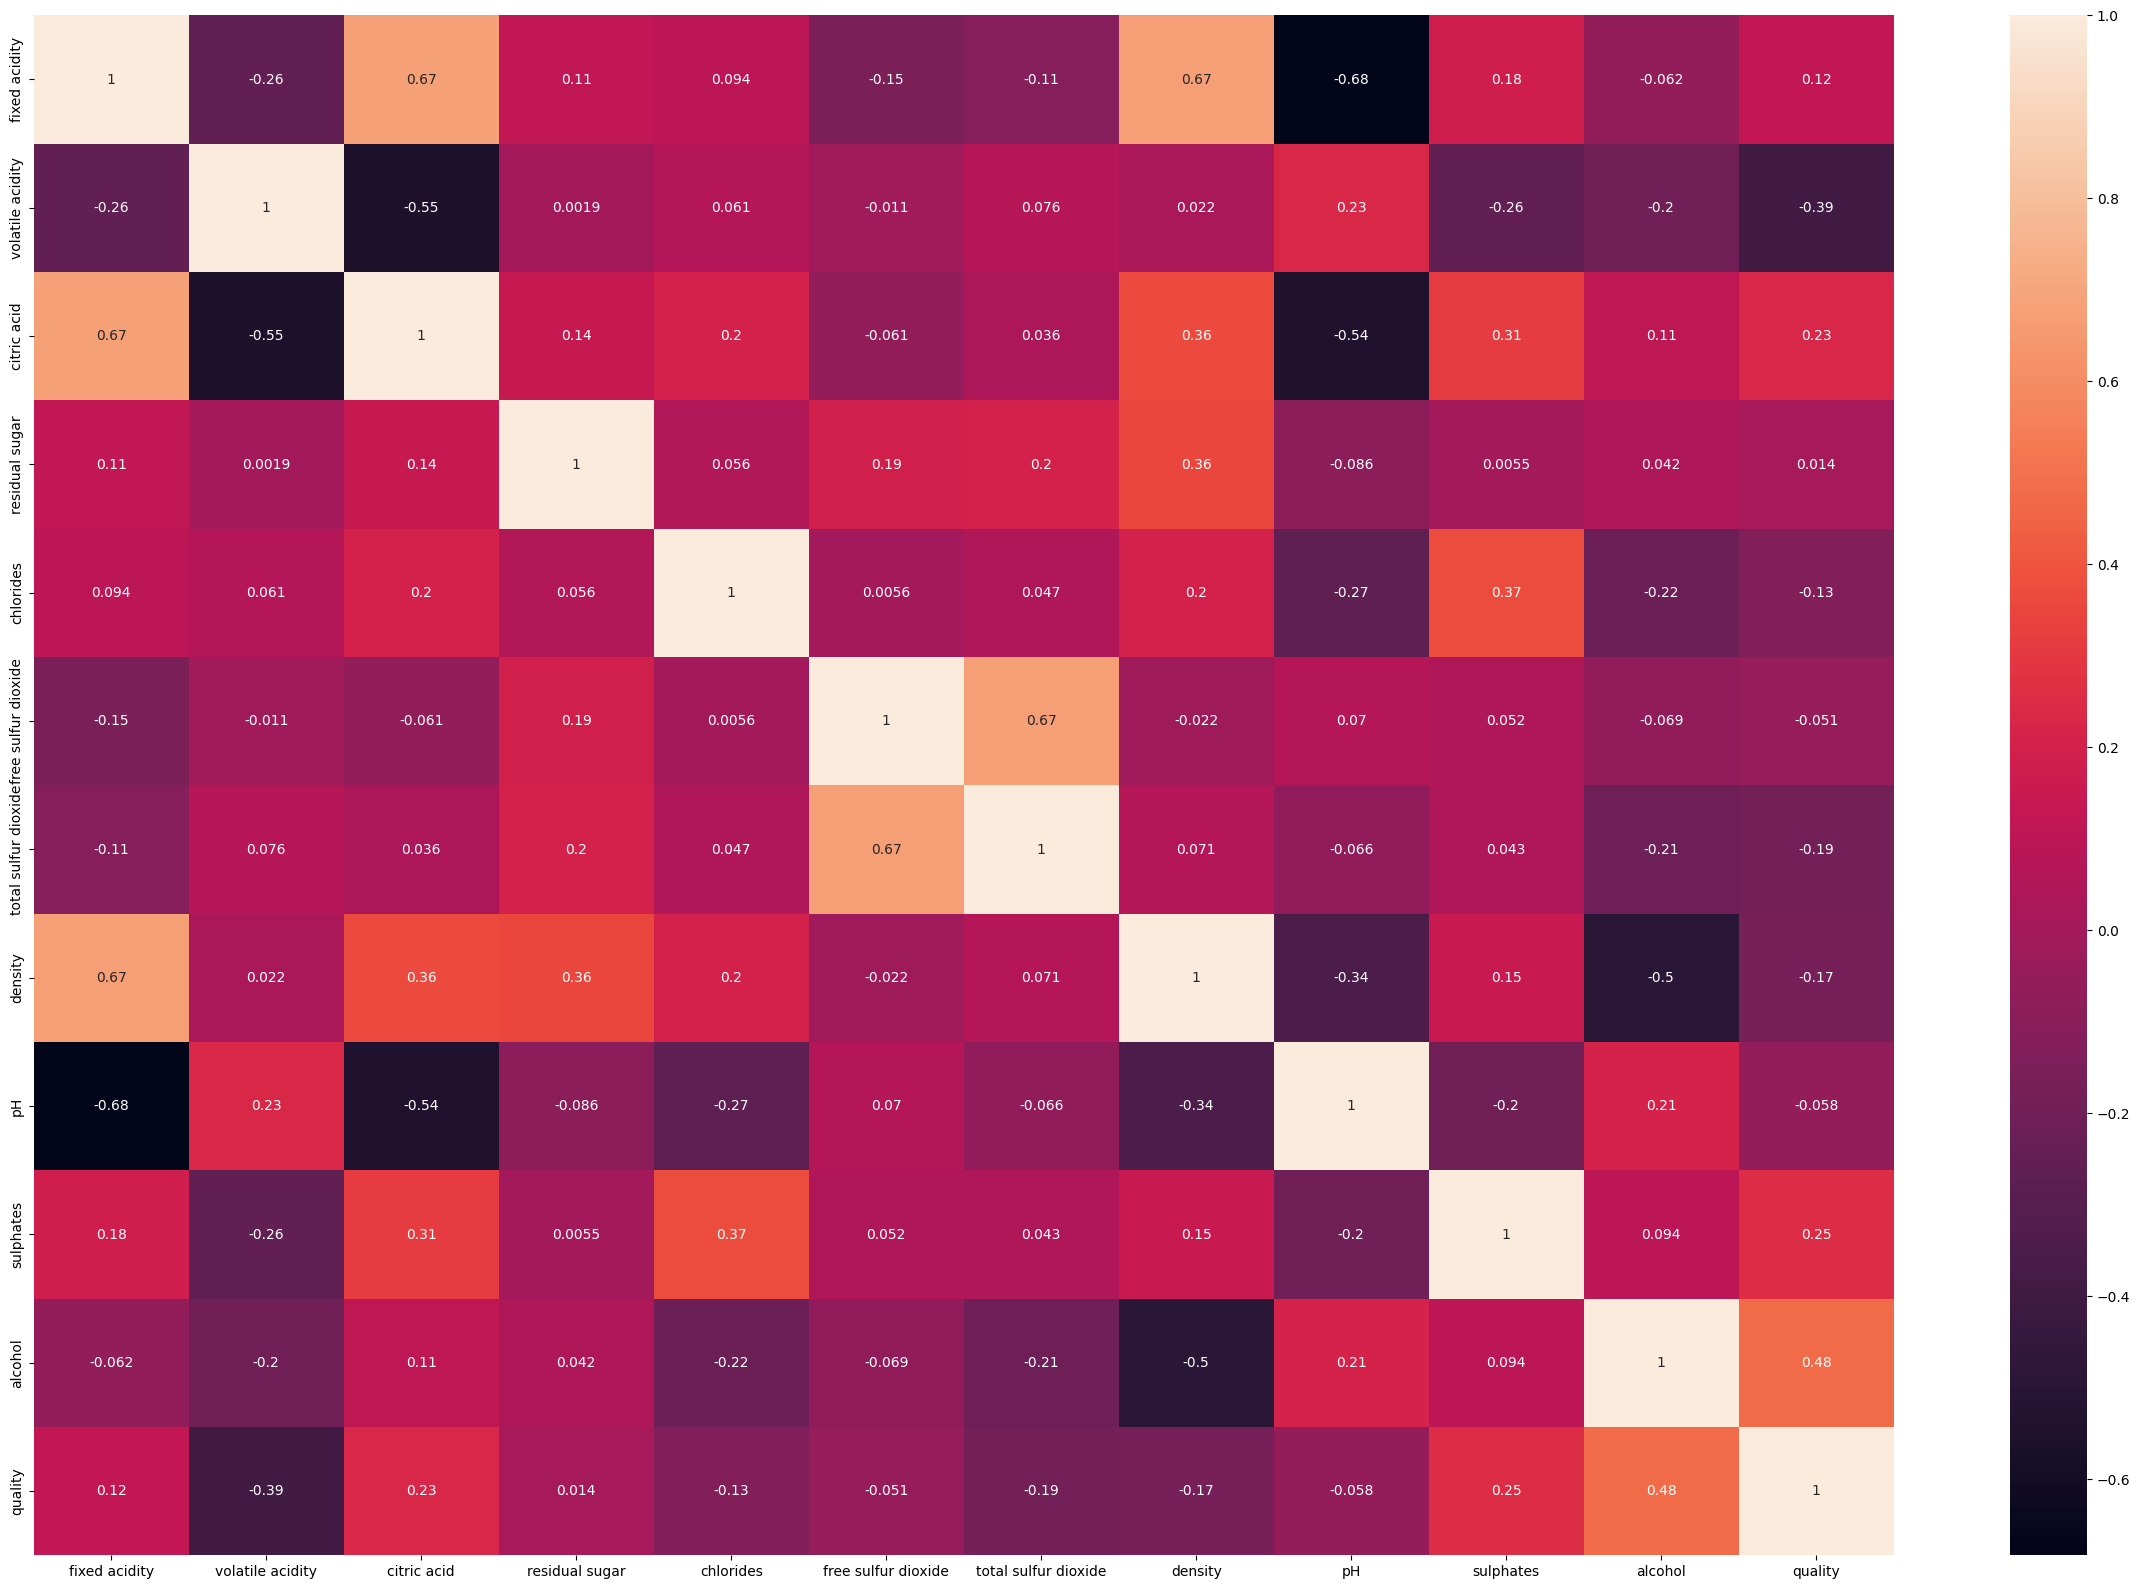

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(30,20))
corr = data.corr()
sns.heatmap(corr, annot=True)
plt.show()
plt.savefig("Correlation_Matrix.png")

In [27]:
!pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 20.6 MB/s eta 0:00:0000:0100:01


In [28]:
from scipy import stats
z = np.abs(stats.zscore(data))
print(z)

[[0.52835961 0.96187667 1.39147228 ... 0.57920652 0.96024611 0.78782264]
 [0.29854743 1.96744245 1.39147228 ... 0.1289504  0.58477711 0.78782264]
 [0.29854743 1.29706527 1.18607043 ... 0.04808883 0.58477711 0.78782264]
 ...
 [1.1603431  0.09955388 0.72391627 ... 0.54204194 0.54162988 0.45084835]
 [1.39015528 0.65462046 0.77526673 ... 0.30598963 0.20930812 0.78782264]
 [1.33270223 1.21684919 1.02199944 ... 0.01092425 0.54162988 0.45084835]]


In [29]:
print(np.where(z>3))

(array([  13,   14,   15,   15,   17,   17,   19,   33,   38,   42,   43,
         45,   57,   81,   81,   83,   86,   88,   91,   92,   95,  106,
        106,  109,  120,  126,  127,  142,  144,  147,  151,  151,  151,
        151,  163,  164,  169,  169,  181,  199,  226,  226,  240,  243,
        244,  258,  258,  274,  281,  291,  324,  325,  339,  340,  347,
        354,  374,  381,  391,  396,  396,  400,  400,  442,  442,  451,
        459,  467,  480,  480,  494,  515,  517,  544,  554,  554,  555,
        555,  557,  557,  568,  584,  588,  591,  595,  608,  614,  636,
        639,  649,  649,  651,  652,  652,  652,  672,  672,  684,  690,
        690,  692,  692,  695,  723,  724,  730,  754,  776,  777,  795,
        821,  832,  836,  837,  889,  899,  911,  917,  923,  925,  926,
        982, 1017, 1018, 1043, 1051, 1051, 1071, 1074, 1079, 1079, 1081,
       1081, 1111, 1114, 1131, 1154, 1165, 1175, 1186, 1231, 1235, 1244,
       1244, 1244, 1260, 1269, 1269, 1270, 1270, 1

In [30]:
clean_data = data[(z < 3).all(axis=1)]

In [31]:
clean_data.shape

(1451, 12)

In [33]:
data.shape

(1599, 12)

In [37]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [38]:
from sklearn.model_selection import train_test_split
x = clean_data.drop(columns = 'quality')
y = clean_data['quality']

In [39]:
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [40]:
y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1451, dtype: int64

In [41]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf_classificationModel = RandomForestClassifier(n_estimators = 100)


In [43]:
rf_classificationModel.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred = rf_classificationModel.predict(X_test)

In [46]:
y_pred

array([5, 6, 6, 5, 5, 6, 5, 7, 6, 6, 6, 5, 5, 5, 5, 5, 6, 7, 5, 6, 5, 5,
       6, 6, 5, 5, 5, 6, 5, 6, 6, 6, 7, 5, 5, 5, 6, 6, 5, 5, 7, 5, 5, 6,
       5, 5, 6, 5, 5, 7, 6, 7, 6, 5, 5, 5, 5, 6, 5, 6, 5, 5, 6, 5, 5, 7,
       5, 7, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 5, 6, 5, 7, 5, 5, 7,
       6, 5, 6, 6, 5, 6, 5, 5, 5, 5, 6, 5, 5, 5, 6, 5, 6, 5, 5, 6, 6, 5,
       5, 5, 7, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 7, 5, 7, 5, 5, 5, 6, 5,
       5, 6, 5, 5, 5, 5, 6, 6, 5, 8, 6, 5, 6, 6, 6, 5, 6, 5, 5, 5, 7, 5,
       7, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 6, 6, 6, 5, 5, 5, 6, 6, 5, 5, 5,
       5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 5, 6, 6, 5, 6, 7, 5, 5, 6, 6, 6, 5,
       7, 5, 6, 6, 7, 5, 6, 5, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 5, 6, 5, 7,
       5, 6, 5, 6, 5, 6, 7, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 5, 7, 6, 5,
       5, 6, 6, 5, 5, 5, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 7, 5, 5, 6, 5,
       6, 5, 6, 6, 5, 7, 5, 6, 5, 7, 5, 5, 5, 5, 6, 6, 5, 7, 6, 6, 5, 5,
       5, 6, 5, 6, 5])

In [50]:
from sklearn import metrics
print("Accuracy Score", metrics.accuracy_score(y_test,y_pred))

Accuracy Score 0.7697594501718213


[Text(0.5131040335463258, 0.975, 'x[2] <= 0.295\ngini = 0.635\nsamples = 719\nvalue = [48, 512, 458, 131, 11]'),
 Text(0.2250399361022364, 0.925, 'x[9] <= 0.555\ngini = 0.574\nsamples = 413\nvalue = [34, 365, 242, 33, 1]'),
 Text(0.3690719848242811, 0.95, 'True  '),
 Text(0.1003727369542066, 0.875, 'x[8] <= 3.385\ngini = 0.436\nsamples = 147\nvalue = [18.0, 179.0, 51.0, 1.0, 0.0]'),
 Text(0.0516506922257721, 0.825, 'x[5] <= 36.0\ngini = 0.36\nsamples = 103\nvalue = [12, 134, 25, 0, 0]'),
 Text(0.04739084132055378, 0.775, 'x[5] <= 4.5\ngini = 0.342\nsamples = 101\nvalue = [12, 134, 22, 0, 0]'),
 Text(0.01703940362087327, 0.725, 'x[7] <= 0.995\ngini = 0.615\nsamples = 8\nvalue = [5, 6, 2, 0, 0]'),
 Text(0.008519701810436636, 0.675, 'x[1] <= 0.59\ngini = 0.48\nsamples = 3\nvalue = [3, 0, 2, 0, 0]'),
 Text(0.004259850905218318, 0.625, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2, 0, 0]'),
 Text(0.012779552715654952, 0.625, 'gini = 0.0\nsamples = 1\nvalue = [3, 0, 0, 0, 0]'),
 Text(0.02555910

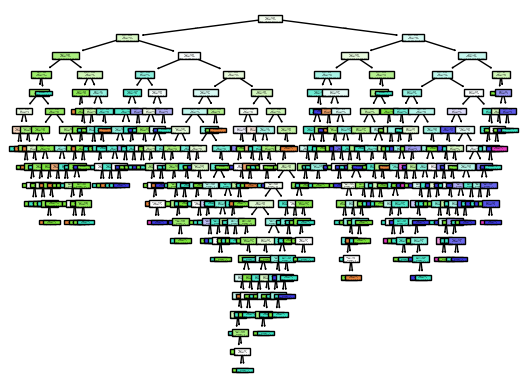

In [51]:
from sklearn import tree
tree.plot_tree(rf_classificationModel.estimators_[0], filled=True)

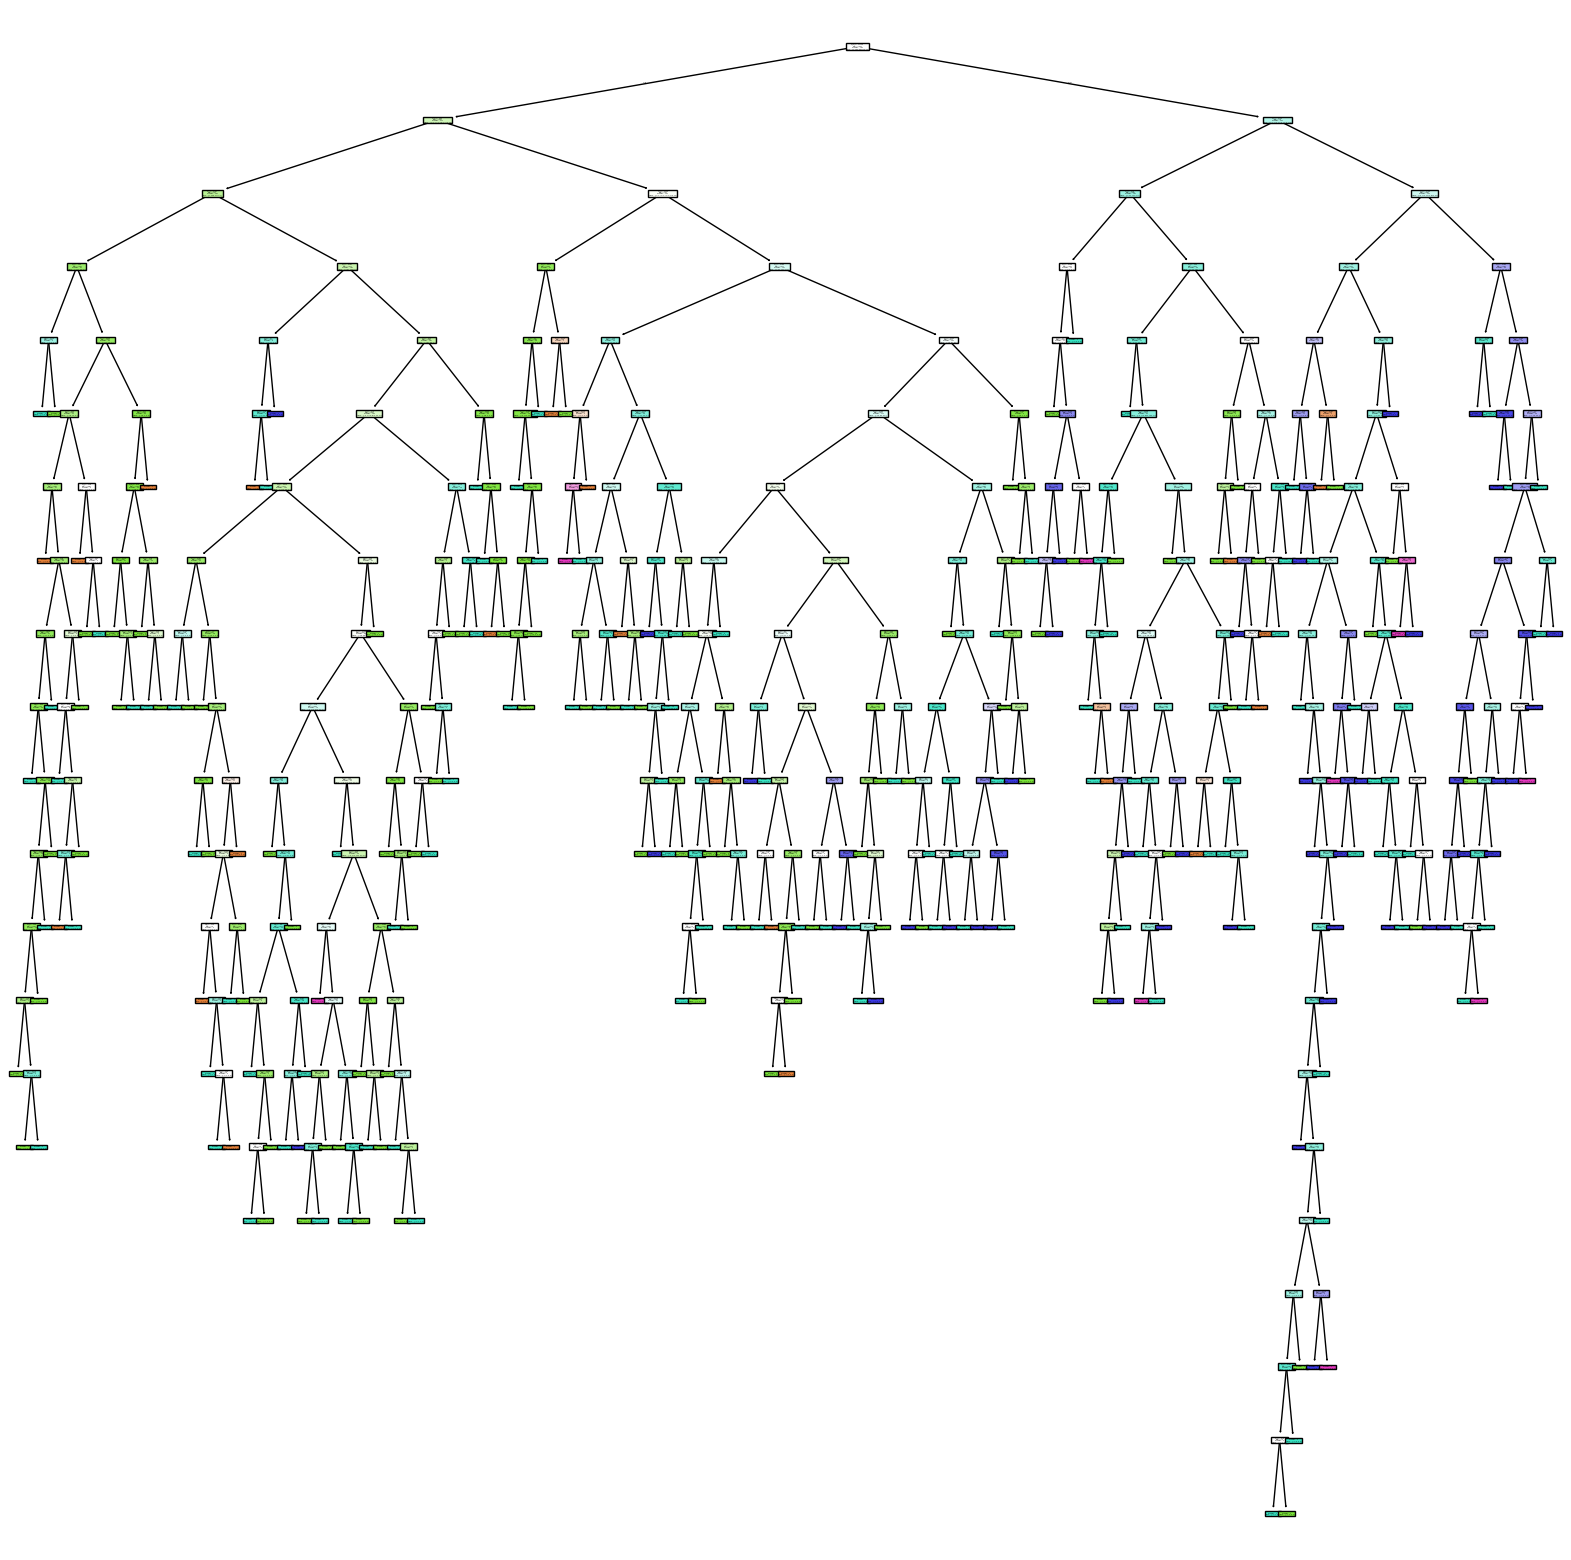

In [54]:
plt.figure(figsize=(20,20))
for i in range(len(rf_classificationModel.estimators_)):
    tree.plot_tree(rf_classificationModel.estimators_[i], filled=True)